In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:

# =====================================================
# CONFIG
# =====================================================

REPO_RAW_BASE = "https://raw.githubusercontent.com/nehamariamjose/cusat-summer-internship-ml/main"
DATA_DIR = "data"
DATA_FILENAME = "stock_data.csv"
DATA_PATH = os.path.join(DATA_DIR, DATA_FILENAME)
DATA_URL = f"{REPO_RAW_BASE}/{DATA_DIR}/{DATA_FILENAME}"

WINDOW_SIZE = 5      # T: number of past days used to predict next-day close
INPUT_SIZE = 1        # d
HIDDEN_SIZE = 8        # h
OUTPUT_SIZE = 1        # k

LEARNING_RATE = 0.001
EPOCHS = 1000

TEST_SIZE = 0.2
RANDOM_STATE = 42   # train/test split seed
RANDOM_SEED = 42     # weight init / framework seed

np.random.seed(RANDOM_SEED)


# =====================================================
# LOAD DATA (self-downloads into shared data/ folder if missing)
# =====================================================

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

df = pd.read_csv(DATA_PATH)

prices = df["Close"].values  # 1D array, ascending date order


In [3]:
# =====================================================
# BUILD SLIDING WINDOWS (T -> next-day close)
# =====================================================

X_list = []
y_list = []

for i in range(WINDOW_SIZE, len(prices)):
    X_list.append(prices[i - WINDOW_SIZE:i])
    y_list.append(prices[i])

X = np.array(X_list)              # shape (N, T)
y = np.array(y_list).reshape(-1, 1)  # shape (N, 1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
print(X_train.shape)
print(y_train.shape)

# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)

# =====================================================
# WEIGHTS (forget, input, output, candidate gates)
# =====================================================

Wxf = np.random.randn(HIDDEN_SIZE, INPUT_SIZE) * 0.1
Whf = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE) * 0.1
bf = np.zeros((HIDDEN_SIZE, 1))

Wxi = np.random.randn(HIDDEN_SIZE, INPUT_SIZE) * 0.1
Whi = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE) * 0.1
bi = np.zeros((HIDDEN_SIZE, 1))

Wxo = np.random.randn(HIDDEN_SIZE, INPUT_SIZE) * 0.1
Who = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE) * 0.1
bo = np.zeros((HIDDEN_SIZE, 1))

Wxg = np.random.randn(HIDDEN_SIZE, INPUT_SIZE) * 0.1
Whg = np.random.randn(HIDDEN_SIZE, HIDDEN_SIZE) * 0.1
bg = np.zeros((HIDDEN_SIZE, 1))

Why = np.random.randn(OUTPUT_SIZE, HIDDEN_SIZE) * 0.1
by = np.zeros((OUTPUT_SIZE, 1))

# =====================================================


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

(396, 5)
(396, 1)


In [4]:
# =====================================================
# TRAINING
# =====================================================

for epoch in range(EPOCHS):

    total_loss = 0

    for n in range(len(X_train)):

        # ==========================================
        # INITIAL HIDDEN / CELL STATE
        # ==========================================

        h_prev = np.zeros((HIDDEN_SIZE, 1))
        c_prev = np.zeros((HIDDEN_SIZE, 1))

        xs = []
        hs = [h_prev]   # hs[0] = initial hidden state (zeros)
        cs = [c_prev]   # cs[0] = initial cell state (zeros)
        fs = []
        i_s = []
        os_ = []
        gs = []

        # ==========================================
        # FORWARD PASS
        # ==========================================

        for t in range(WINDOW_SIZE):

            x_t = np.array([[X_train[n, t]]])

            f_t = sigmoid(Wxf @ x_t + Whf @ hs[-1] + bf)
            i_t = sigmoid(Wxi @ x_t + Whi @ hs[-1] + bi)
            o_t = sigmoid(Wxo @ x_t + Who @ hs[-1] + bo)
            g_t = np.tanh(Wxg @ x_t + Whg @ hs[-1] + bg)

            c_t = f_t * cs[-1] + i_t * g_t
            h_t = o_t * np.tanh(c_t)

            xs.append(x_t)
            fs.append(f_t)
            i_s.append(i_t)
            os_.append(o_t)
            gs.append(g_t)
            cs.append(c_t)
            hs.append(h_t)

        y_hat = Why @ hs[WINDOW_SIZE] + by

        target = np.array([[y_train[n, 0]]])

        loss = 0.5 * np.sum((y_hat - target) ** 2)

        total_loss += loss

        # ==========================================
        # OUTPUT LAYER GRADIENT
        # ==========================================

        dy = y_hat - target

        dWhy = dy @ hs[WINDOW_SIZE].T
        dby = dy

        # ==========================================
        # BPTT THROUGH LSTM GATES
        # ==========================================

        dWxf = np.zeros_like(Wxf); dWhf = np.zeros_like(Whf); dbf = np.zeros_like(bf)
        dWxi = np.zeros_like(Wxi); dWhi = np.zeros_like(Whi); dbi = np.zeros_like(bi)
        dWxo = np.zeros_like(Wxo); dWho = np.zeros_like(Who); dbo = np.zeros_like(bo)
        dWxg = np.zeros_like(Wxg); dWhg = np.zeros_like(Whg); dbg = np.zeros_like(bg)

        dh_next = Why.T @ dy  # dh_T
        dc_next = np.zeros((HIDDEN_SIZE, 1))  # no future timestep beyond T

        for t in reversed(range(WINDOW_SIZE)):  # t = T-1, ..., 0

            f_t = fs[t]
            i_t = i_s[t]
            o_t = os_[t]
            g_t = gs[t]

            c_t = cs[t + 1]
            c_prev = cs[t]
            h_prev = hs[t]

            tanh_c = np.tanh(c_t)

            dh = dh_next

            do = dh * tanh_c
            dc = dh * o_t * (1 - tanh_c ** 2) + dc_next

            df = dc * c_prev
            di = dc * g_t
            dg = dc * i_t

            da_f = df * f_t * (1 - f_t)      # sigmoid'
            da_i = di * i_t * (1 - i_t)      # sigmoid'
            da_o = do * o_t * (1 - o_t)      # sigmoid'
            da_g = dg * (1 - g_t ** 2)       # tanh'

            dWxf += da_f @ xs[t].T
            dWhf += da_f @ h_prev.T
            dbf += da_f

            dWxi += da_i @ xs[t].T
            dWhi += da_i @ h_prev.T
            dbi += da_i

            dWxo += da_o @ xs[t].T
            dWho += da_o @ h_prev.T
            dbo += da_o

            dWxg += da_g @ xs[t].T
            dWhg += da_g @ h_prev.T
            dbg += da_g

            dh_prev = (
                Whf.T @ da_f +
                Whi.T @ da_i +
                Who.T @ da_o +
                Whg.T @ da_g
            )
            dc_prev = dc * f_t

            dh_next = dh_prev
            dc_next = dc_prev

        # ==========================================
        # WEIGHT UPDATE
        # ==========================================

        Wxf -= LEARNING_RATE * dWxf; Whf -= LEARNING_RATE * dWhf; bf -= LEARNING_RATE * dbf
        Wxi -= LEARNING_RATE * dWxi; Whi -= LEARNING_RATE * dWhi; bi -= LEARNING_RATE * dbi
        Wxo -= LEARNING_RATE * dWxo; Who -= LEARNING_RATE * dWho; bo -= LEARNING_RATE * dbo
        Wxg -= LEARNING_RATE * dWxg; Whg -= LEARNING_RATE * dWhg; bg -= LEARNING_RATE * dbg

        Why -= LEARNING_RATE * dWhy
        by -= LEARNING_RATE * dby

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}  Loss = {total_loss/len(X_train):.6f}"
        )

Epoch    0  Loss = 0.501042
Epoch  100  Loss = 0.020096
Epoch  200  Loss = 0.015878
Epoch  300  Loss = 0.013956
Epoch  400  Loss = 0.012770
Epoch  500  Loss = 0.011950
Epoch  600  Loss = 0.011357
Epoch  700  Loss = 0.010928
Epoch  800  Loss = 0.010623
Epoch  900  Loss = 0.010413


In [5]:
# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

    h_prev = np.zeros((HIDDEN_SIZE, 1))
    c_prev = np.zeros((HIDDEN_SIZE, 1))

    for t in range(WINDOW_SIZE):

        x_t = np.array([[X_test[n, t]]])

        f_t = sigmoid(Wxf @ x_t + Whf @ h_prev + bf)
        i_t = sigmoid(Wxi @ x_t + Whi @ h_prev + bi)
        o_t = sigmoid(Wxo @ x_t + Who @ h_prev + bo)
        g_t = np.tanh(Wxg @ x_t + Whg @ h_prev + bg)

        c_prev = f_t * c_prev + i_t * g_t
        h_prev = o_t * np.tanh(c_prev)

    y_hat = Why @ h_prev + by

    predictions.append(y_hat[0, 0])

predictions = np.array(predictions).reshape(-1, 1)

# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test

# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual, predictions)
mae = mean_absolute_error(actual, predictions)
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")

MSE : 18.0392
MAE : 2.8595


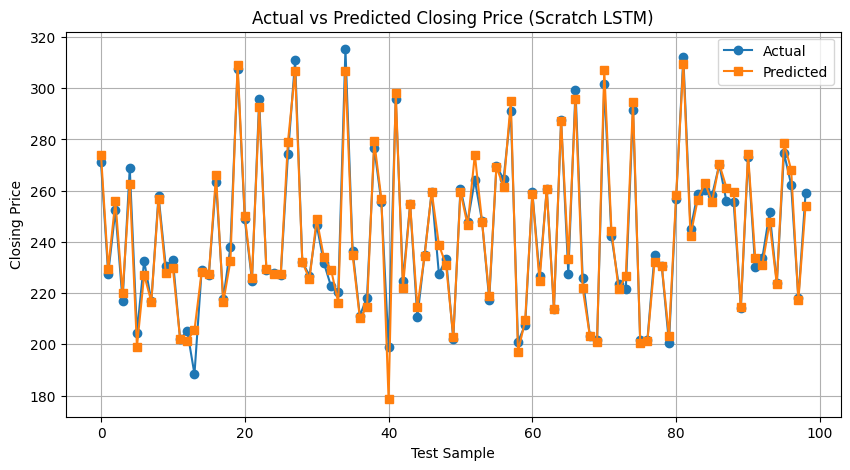

In [6]:
# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(actual, label="Actual", marker='o')
plt.plot(predictions, label="Predicted", marker='s')

plt.xlabel("Test Sample")
plt.ylabel("Closing Price")

plt.title("Actual vs Predicted Closing Price (Scratch LSTM)")

plt.legend()
plt.grid(True)
plt.show()

In [7]:
# ==================  USING TENSORFLOW  ===================== #
# ============================================================ #
# Uses the same X_train/X_test/y_train/y_test, scalers, and
# WINDOW_SIZE/INPUT_SIZE/HIDDEN_SIZE/OUTPUT_SIZE/LEARNING_RATE/EPOCHS
# from the scratch section above; no data loading/scaling repeated.

import tensorflow as tf

tf.random.set_seed(RANDOM_SEED)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Reshape input data for Keras LSTM (samples, timesteps, features)
X_train_keras = X_train.reshape(X_train.shape[0], WINDOW_SIZE, INPUT_SIZE)
X_test_keras = X_test.reshape(X_test.shape[0], WINDOW_SIZE, INPUT_SIZE)

# Build the Keras LSTM model
model = Sequential([
    LSTM(HIDDEN_SIZE, activation='tanh', recurrent_activation='sigmoid', input_shape=(WINDOW_SIZE, INPUT_SIZE)),
    Dense(OUTPUT_SIZE, activation='linear')
])

# Compile the model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='mse')

# Print model summary
model.summary()

# Train the model
model.fit(
    X_train_keras,
    y_train,
    epochs=EPOCHS,
    batch_size=len(X_train_keras),  # full batch, to match scratch version's per-sample update logic roughly
    verbose=0
)

# Make predictions on the test set
keras_predictions_scaled = model.predict(X_test_keras)

# Inverse transform the predictions and actual values
keras_predictions = y_scaler.inverse_transform(keras_predictions_scaled)
keras_actual = y_test  # Already in original scale

# Evaluate the model
keras_mse = mean_squared_error(keras_actual, keras_predictions)
keras_mae = mean_absolute_error(keras_actual, keras_predictions)
print(f"TensorFlow/Keras MSE: {keras_mse:.4f}")
print(f"TensorFlow/Keras MAE: {keras_mae:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
TensorFlow/Keras MSE: 17.6525
TensorFlow/Keras MAE: 2.9239


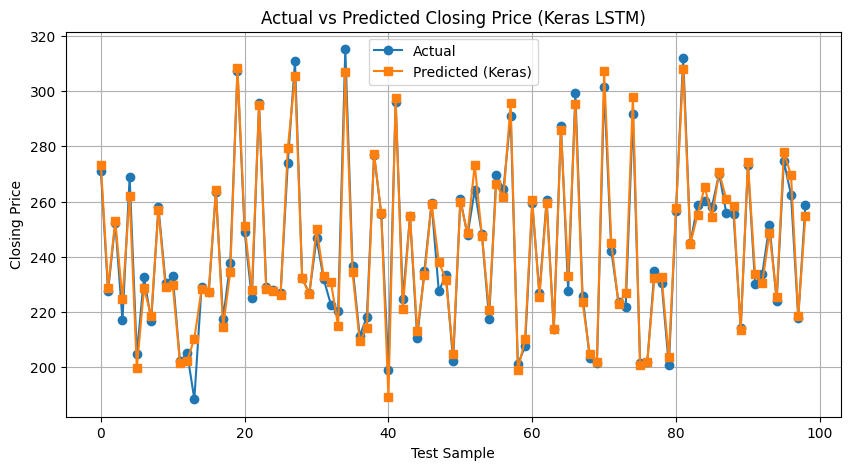

In [8]:
# Plot Actual vs Predicted for Keras
plt.figure(figsize=(10, 5))
plt.plot(keras_actual, label="Actual", marker='o')
plt.plot(keras_predictions, label="Predicted (Keras)", marker='s')
plt.xlabel("Test Sample")
plt.ylabel("Closing Price")
plt.title("Actual vs Predicted Closing Price (Keras LSTM)")
plt.legend()
plt.grid(True)
plt.show()